# 03 — Supervised Fine-Tuning (SFT) with Qwen

Fine-tune a Qwen3.5 model on the DAIC-WOZ clinical interview data using LoRA + TRL's `SFTTrainer`.

The dataset (`daicwoz_finetune.jsonl`) is already in chat format — each line is a full interview formatted as `{"messages": [{role, content}, ...]}`.


In [1]:
import json, random
from pathlib import Path

SP_DATA = Path("../data/self_play/iter_01/sft_data.jsonl")

with open(SP_DATA) as f:
    sp_records = [json.loads(l) for l in f if l.strip()]

random.seed(43)
random.shuffle(sp_records)
split_idx = max(1, int(len(sp_records) * 0.9))

train_out = SP_DATA.parent / "sft_train.jsonl"
val_out = SP_DATA.parent / "sft_val.jsonl"

# Write 90% train split
with open(train_out, "w") as f:
    for r in sp_records[:split_idx]:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

# Write 10% self-play val
with open(val_out, "w") as f:
    for r in sp_records[split_idx:]:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"Train: {split_idx} → {train_out}")
print(f"Val  : {len(sp_records) - split_idx} → {val_out}")

Train: 201 → ../data/self_play/iter_01/sft_train.jsonl
Val  : 23 → ../data/self_play/iter_01/sft_val.jsonl


In [2]:
from dotenv import load_dotenv
load_dotenv("../.env")

import json
import os
from pathlib import Path

import torch
torch.cuda.empty_cache()
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTConfig, SFTTrainer

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX 6000 Ada Generation
VRAM: 50.9 GB


## Configuration

In [3]:
# ── Model ──────────────────────────────────────────────────────────────────
MODEL_NAME = "Qwen/Qwen3.5-4B"

# ── Paths ──────────────────────────────────────────────────────────────────
SSD_ROOT    = Path(os.environ["SSD_ROOT"])
TRAIN_PATH  = Path("../data/self_play/iter_01/sft_train.jsonl")
VAL_PATH    = Path("../data/self_play/iter_01/sft_val.jsonl")
OUTPUT_DIR  = SSD_ROOT / "models/Qwen3.5-4B-SFT-newdata"

# ── LoRA ───────────────────────────────────────────────────────────────────
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05

# ── Training ───────────────────────────────────────────────────────────────
NUM_EPOCHS     = 3
BATCH_SIZE     = 1
GRAD_ACCUM     = 8
LR             = 1e-5

MAX_SEQ_LENGTH = 4096

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Model : {MODEL_NAME}")
print(f"Output: {OUTPUT_DIR}")

Model : Qwen/Qwen3.5-4B
Output: /data_1_8TB_ssd/kevint/models/Qwen3.5-4B-SFT-newdata


## Load Dataset

In [4]:
def load_jsonl(path):
    """Load JSONL records as-is (no trimming, no turn removal)."""
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

train_records = load_jsonl(TRAIN_PATH)
val_records   = load_jsonl(VAL_PATH)

train_dataset = Dataset.from_list(train_records)
val_dataset   = Dataset.from_list(val_records)

print(f"Train: {len(train_dataset)}")
print(f"Val  : {len(val_dataset)}")
print(f"\nExample (first 2 turns):")
for msg in train_dataset[0]["messages"][:2]:
    print(f"  [{msg['role']}]: {msg['content'][:120]!r}")

Train: 201
Val  : 23

Example (first 2 turns):
  [system]: 'You are a skilled CBT (Cognitive Behavioural Therapy) therapist conducting an initial clinical assessment session. Follo'
  [user]: 'Start the session.'


## Load Tokenizer & Model

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"   # required for causal LM training

dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=dtype,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",
)
model.config.use_cache = False
# Explicitly align pad/eos token IDs so transformers doesn't auto-correct and warn
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
if hasattr(model, "generation_config"):
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Parameters  : {total:,}  (trainable before LoRA: {trainable:,})")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

/data_1_8TB_ssd/kevint/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Parameters  : 2,421,206,016  (trainable before LoRA: 636,660,736)


## Apply LoRA

In [6]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 21,233,664 || all params: 4,226,984,960 || trainable%: 0.5023


## Train

In [7]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

sft_config = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    # Logging & saving
    logging_steps=10,
    save_strategy="steps",
    save_steps=10,
    save_total_limit=2,
    # Evaluation
    eval_strategy="steps",
    eval_steps=10,
    per_device_eval_batch_size=BATCH_SIZE,
    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    # Precision
    bf16=use_bf16,
    fp16=(not use_bf16) and torch.cuda.is_available(),
    # Misc
    gradient_checkpointing=True,
    report_to="none",
    max_length=MAX_SEQ_LENGTH,
    dataset_kwargs={"skip_prepare_dataset": False},
    assistant_only_loss=True,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

print("Trainer ready  (assistant-only loss)")
print(f"Steps per epoch : {len(trainer.get_train_dataloader())}")
print(f"Total steps     : {sft_config.max_steps if sft_config.max_steps > 0 else 'auto'}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/201 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/23 [00:00<?, ? examples/s]

Trainer ready  (assistant-only loss)
Steps per epoch : 201
Total steps     : auto


In [8]:
train_result = trainer.train()

print("\n── Training complete ──")
print(f"Runtime    : {train_result.metrics['train_runtime']:.1f}s")
print(f"Samples/s  : {train_result.metrics['train_samples_per_second']:.2f}")
print(f"Final loss : {train_result.metrics['train_loss']:.4f}")


[transformers] Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,0.966749,0.947747,1.032803,167651.000000,0.701192
20,0.891560,0.909892,0.892867,337969.000000,0.712007
30,0.859337,0.890405,0.903669,486243.000000,0.714131
40,0.842642,0.884446,0.873656,655303.000000,0.714741
50,0.836255,0.879817,0.874964,829084.000000,0.716258
60,0.801468,0.877968,0.866589,983282.000000,0.717362
70,0.810973,0.877554,0.862833,1153622.000000,0.717545
78,0.810973,0.877683,0.863005,1273920.000000,0.717205



── Training complete ──
Runtime    : 716.2s
Samples/s  : 0.84
Final loss : 0.8544


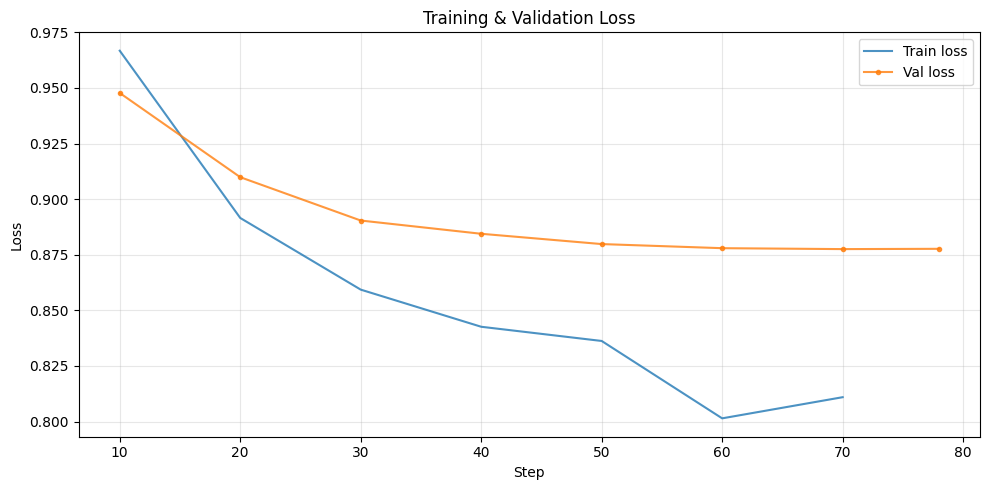

In [9]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [e["step"] for e in log_history if "loss" in e]
train_loss  = [e["loss"] for e in log_history if "loss" in e]
eval_steps  = [e["step"] for e in log_history if "eval_loss" in e]
eval_loss   = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Train loss", alpha=0.8)
ax.plot(eval_steps,  eval_loss,  label="Val loss",   alpha=0.8, marker="o", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Save Model

In [10]:
adapter_dir = OUTPUT_DIR / "lora-adapters"
model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))
print(f"LoRA adapters saved → {adapter_dir}")

LoRA adapters saved → /data_1_8TB_ssd/kevint/models/Qwen3.5-4B-SFT-newdata/lora-adapters
